# 🧬 Pipeline scRNA-seq — IBD Colon/Recto - GSE214695

## Normalización y selección de genes variables

**Flujo de trabajo:**
1. Cargar archivos `.h5ad`
2. Para **cada muestra**: normalización -> combinación -> selección genes variables

**Orden de pasos:**
1. Concatenar las 18 muestras → objeto único (sparse, sin NaN)
2. Guardar conteos crudos en .raw  
3. Normalizar: counts per 10.000 + log1p  
4. Selección de genes altamente variables (HVG)
5. Escalar SOLO HVGs
6. PCA sobre HVGs escalados


# · Importaciones y configuración

In [ ]:
# Montar Google Drive y prepara el gestor de entornos Conda
from google.colab import drive
drive.mount('/content/drive')

!pip install -q condacolab
import condacolab
condacolab.install()

Mounted at /content/drive
⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:16
🔁 Restarting kernel...


In [ ]:
# Instalación del entorno Conda del proyecto (environment.yml), con las
# versiones exactas de todas las dependencias fijadas para reproducibilidad.

!conda env update -n base -f /content/drive/MyDrive/TFM_IBD_GSE214695/environment.yml -q

Retrieving notices: ...working... done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Installing pip dependencies: ...working... done


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import gc, os
import glob
from pathlib import Path
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import yaml

sc.settings.verbosity = 2

# · Configuración de rutas

In [ ]:
REPO_ROOT = Path("/content/drive/MyDrive/TFM_IBD_GSE214695")
with open(REPO_ROOT / "config" / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)

PROJECT_ROOT = os.environ.get(PARAMS["project_root_env_var"], PARAMS["project_root_default"])

FILTERED_DIR = f"{PROJECT_ROOT}/{PARAMS['paths']['interim']['01_qc_filtered']}"
OUTPUT_DIR   = f"{PROJECT_ROOT}/{PARAMS['paths']['interim']['02_normalized']}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
FIGURES_DIR = f"{REPO_ROOT}/{PARAMS['paths']['reports']['figures']['02_normalization']}"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGURES_DIR

#TARGET_SUM = 10000
TARGET_SUM = PARAMS["pipeline"]["target_sum_cpm"]
N_HVG      = PARAMS["pipeline"]["n_hvg"]
N_PCS      = 50
BATCH_KEY  = PARAMS["pipeline"]["batch_key"]

In [ ]:
h5ad_files = sorted(glob.glob(f"{FILTERED_DIR}/*_filtered.h5ad"))
if not h5ad_files:
    raise FileNotFoundError(f"No se encontraron archivos en {FILTERED_DIR}")

print(f"Cargando {len(h5ad_files)} archivos filtrados...")
adatas = []
for f in h5ad_files:
    sample_name = Path(f).stem.replace("_filtered", "")
    tmp = sc.read_h5ad(f)
    # Añadir el nombre de la muestra como metadato de cada célula.
    # Necesario para que Harmony sepa a qué muestra pertenece cada célula cuando corrija el batch effect.
    tmp.obs[BATCH_KEY] = sample_name
    adatas.append(tmp)
    print(f"   {sample_name}: {tmp.n_obs:,} células × {tmp.n_vars:,} genes")
    del tmp; gc.collect() # liberar RAM

# Concatenar todas las muestras en un único objeto AnnData.
# join='outer': conserva TODOS los genes de todas las muestras.
# Los genes presentes en unas muestras pero no en otras son biológicamente
# reales. Se aplica fill_value=0 para otorgarles valor 0.

print("\n→ Concatenando muestras (join='outer', fill_value=0)...")
adata = ad.concat(
    adatas, join='outer', label=BATCH_KEY,
    keys=[a.obs[BATCH_KEY][0] for a in adatas],
    fill_value=0
)
del adatas; gc.collect()

print(f"   Objeto combinado: {adata.n_obs:,} células × {adata.n_vars:,} genes")
print(f"   Muestras: {adata.obs[BATCH_KEY].nunique()}")
print(f"   X es sparse: {sp.issparse(adata.X)}")
if sp.issparse(adata.X):
    print(f"   RAM ocupada por X (sparse .data): "
          f"{adata.X.data.nbytes / 1024**3:.2f} GB")

# Verificar ausencia de NaN
x_data = adata.X.data if sp.issparse(adata.X) else adata.X
assert not np.isnan(x_data).any(), "NaN detectados tras concatenación"
print("Sin NaN")


Cargando 18 archivos filtrados...
   GSM6614348_HC-1: 1,455 células × 33,538 genes
   GSM6614349_HC-2: 2,848 células × 33,538 genes
   GSM6614350_HC-3: 3,082 células × 33,538 genes
   GSM6614351_HC-4: 2,031 células × 33,538 genes
   GSM6614352_HC-5: 3,082 células × 33,538 genes
   GSM6614353_HC-6: 1,604 células × 33,538 genes
   GSM6614354_UC-1: 1,311 células × 33,538 genes
   GSM6614355_UC-2: 2,451 células × 33,538 genes
   GSM6614356_UC-3: 2,033 células × 33,538 genes
   GSM6614357_UC-4: 2,922 células × 33,538 genes
   GSM6614358_UC-5: 2,583 células × 33,538 genes
   GSM6614359_UC-6: 2,910 células × 33,538 genes
   GSM6614360_CD-1: 2,659 células × 33,538 genes
   GSM6614361_CD-2: 1,450 células × 33,538 genes
   GSM6614362_CD-3: 3,081 células × 33,538 genes
   GSM6614363_CD-4: 2,226 células × 33,538 genes
   GSM6614364_CD-5: 1,227 células × 33,538 genes
   GSM6614365_CD-6: 4,433 células × 33,538 genes

→ Concatenando muestras (join='outer', fill_value=0)...
   Objeto combinado: 43,388

# · Guardar conteos crudos en .raw




In [ ]:
print("\n→ Guardando conteos crudos en .raw ...")
adata.raw = adata.copy()
print(f"adata.raw guardado (sparse: {sp.issparse(adata.raw.X)})")


→ Guardando conteos crudos en .raw ...
adata.raw guardado (sparse: True)


# 🔬 Normalización: CPM + log1p




In [ ]:
print("\n→ Normalizando (CPM + log1p)...")
sc.pp.normalize_total(adata, target_sum=TARGET_SUM)
sc.pp.log1p(adata)

print(f"   X sigue sparse: {sp.issparse(adata.X)}")
x_data = adata.X.data if sp.issparse(adata.X) else adata.X
assert not np.isnan(x_data).any(), "NaN detectados tras normalización"
print("Normalización completada. Sin NaN.")



→ Normalizando (CPM + log1p)...
normalizing counts per cell
    finished (0:00:00)
   X sigue sparse: True
Normalización completada. Sin NaN.


# · Selección de genes altamente variables (HVG)



In [ ]:
#   Con batch_key, los HVGs se seleccionan dentro de cada muestra
#   por separado y se combina el resultado — solo pasan genes que varían
#   consistentemente en múltiples muestras.

# Se detectó a posteriori que esta llamada opera sobre adata.X ya normalizado
# (CPM+log1p), cuando flavor='seurat_v3' está documentado para conteos crudos.
# El impacto cuantificado de HVGs frente al cálculo correcto sobre adata.raw
# se encuentra en el apartado de limitaciones. No se corrige en esta versión por tiempo.

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_HVG,
    flavor='seurat_v3',
    batch_key=BATCH_KEY,
    subset=False    #   Marca los HVGs en .var['highly_variable'] sin eliminar el
                    #   resto de genes (que se necesitan para análisis posteriores).
)
n_hvg = adata.var['highly_variable'].sum()
print(f"{n_hvg:,} HVGs de {adata.n_vars:,} genes totales")


extracting highly variable genes
3,000 HVGs de 33,538 genes totales


# · Escalar solo los HVGs


In [ ]:
# Aplicar sc.pp.scale() sobre todos los genes densifica hasta los 10 GB
# Lo mejor es escalar solo el subobjeto de HVGs que llega a 1 GB
# El subobjeto se usa para PCA y se elimina tras transferir los resultados.

adata_hvg = adata[:, adata.var['highly_variable']].copy()
ram_est = adata_hvg.n_obs * adata_hvg.n_vars * 4 / 1024**3  # float32
print(f"RAM estimada del subobjeto HVG escalado: ~{ram_est:.1f} GB")

sc.pp.scale(adata_hvg, max_value=10)  # limita los valores escalados a ±10.
#   Evita que células con expresión extrema de algún gen (outliers) distorsionen el PCA.

print(f"X HVG es densa tras scale: {not sp.issparse(adata_hvg.X)}")
print("Escalado completado")


RAM estimada del subobjeto HVG escalado: ~0.5 GB
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
X HVG es densa tras scale: True
Escalado completado


# · PCA sobre HVGs escalados





→ Calculando PCA (50 componentes sobre 3,000 HVGs escalados)...
computing PCA
    with n_comps=50
    finished (0:00:23)


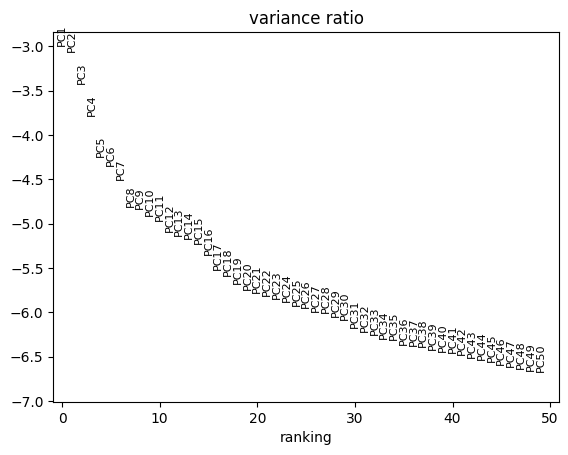

PCA completado.


47330

In [ ]:
# sc.tl.pca sobre el subobjeto de HVGs.

print(f"\n→ Calculando PCA ({N_PCS} componentes sobre {n_hvg:,} HVGs escalados)...")
sc.tl.pca(adata_hvg, n_comps=N_PCS, svd_solver='arpack', random_state=42)

# svd_solver='arpack' es para matrices sparse/grandes.

# Transferir solo X_pca (coordenadas de cada célula en el espacio PCA) al objeto principal.
adata.obsm['X_pca'] = adata_hvg.obsm['X_pca']
adata.uns['pca']    = adata_hvg.uns['pca']

# Elbow plot muestra la varianza explicada por cada componente PCA.
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=N_PCS, log=True,
                         save="_elbow_plot.png")
print(f"PCA completado.")

del adata_hvg; gc.collect()


# · GUARDAR OBJETO NORMALIZADO

El objeto guardado contiene:
- adata.X       → datos normalizados (CPM + log1p), sparse
- adata.raw     → conteos crudos originales para DEG, sparse
- adata.var     → metadatos de genes, incluyendo 'highly_variable'
- adata.obs     → metadatos de células, incluyendo 'sample_id'
- adata.obsm['X_pca'] → coordenadas PCA para Harmony
- adata.uns['pca']    → varianza explicada por cada PC (para el elbow plot)


In [ ]:
out_path = f"{OUTPUT_DIR}/IBD_normalized.h5ad"
print(f"\n→ Guardando en {out_path} ...")
adata.write_h5ad(out_path, compression='gzip')

print(f"  NORMALIZACIÓN COMPLETADA")
print(f"  Células              : {adata.n_obs:,}")
print(f"  Genes totales        : {adata.n_vars:,}")
print(f"  HVGs marcados        : {adata.var['highly_variable'].sum():,}")
print(f"  .raw (crudos)        : {adata.raw is not None}")
print(f"  .X (log1p+CPM)       : sparse={sp.issparse(adata.X)}")
print(f"  obsm['X_pca']        : {adata.obsm['X_pca'].shape}")
print(f"{'='*60}")



→ Guardando en /content/drive/MyDrive/IBD_TFM/data/interim/02_normalized/IBD_normalized.h5ad ...
  NORMALIZACIÓN COMPLETADA
  Células              : 43,388
  Genes totales        : 33,538
  HVGs marcados        : 3,000
  .raw (crudos)        : True
  .X (log1p+CPM)       : sparse=True
  obsm['X_pca']        : (43388, 50)
